# Network Analysis: Node Degrees and Bipartite Graphs by Community

This notebook analyzes network data to:
1. Calculate node degrees based on edge connections
2. Identify the X most and Y least connected nodes in each community
3. Visualize bipartite graphs for communities 0, 1, 2 based on the "set" attribute

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

In [61]:
# Load the data
nodes_df = pd.read_csv('../data/processed/us/nodes.csv')
edges_df = pd.read_csv('../data/processed/us/edges.csv')

print(f"Nodes shape: {nodes_df.shape}")
print(f"Edges shape: {edges_df.shape}")
print(f"\nNumber of unique communities: {nodes_df['community_id'].nunique()}")
print(f"\nNodes DataFrame columns: {nodes_df.columns.tolist()}")
print(f"Edges DataFrame columns: {edges_df.columns.tolist()}")

Nodes shape: (15347, 7)
Edges shape: (156481, 24)

Number of unique communities: 171

Nodes DataFrame columns: ['index', 'index.1', 'community_id', 'node', 'community_size', 'id', 'set']
Edges DataFrame columns: ['index', 'investor_name_left', 'investor_name_right', 'announced_year_left', 'announced_year_right', 'org_uuid', 'total_funding_usd', 'total_funding_usd_left', 'total_funding_usd_right', 'year', 'company_country', 'investor_country_left', 'investor_country_right', 'investor_region_left', 'investor_region_right', 'investment_type_left', 'investment_type_right', 'category_left', 'category_right', 'community_left', 'community_right', 'community', 'Source', 'Target']


In [62]:
# Display sample data
print("Sample Nodes Data:")
print(nodes_df.head())
print("\n" + "="*80 + "\n")
print("Sample Edges Data:")
print(edges_df.head())

Sample Nodes Data:
   index  index.1  community_id                          node  community_size  \
0      0        0             0  Ironspring Ventures-series_a            4212   
1      1        1             0                 Bolt-series_a            4212   
2      2        2             0          NightDragon-series_e            4212   
3      3        3             0                Xfund-series_e            4212   
4      4        4             0   Borderless Capital-series_b            4212   

                             id  set  
0  Ironspring Ventures-series_a    1  
1                 Bolt-series_a    1  
2          NightDragon-series_e    0  
3                Xfund-series_e    0  
4   Borderless Capital-series_b    0  


Sample Edges Data:
   index  investor_name_left         investor_name_right  announced_year_left  \
0      0  Benchmark-series_c              Accel-series_a                 2007   
1      2  Benchmark-series_c    Sequoia Capital-series_a                 2007

## Step 1: Calculate Node Degrees

Calculate the degree (number of connections) for each node based on the edges data.

In [63]:
# Calculate degree for each node by counting occurrences in Source and Target columns
source_degrees = edges_df['Source'].value_counts()
target_degrees = edges_df['Target'].value_counts()

# Combine degrees (a node can appear as both source and target)
all_degrees = pd.concat([source_degrees, target_degrees]).groupby(level=0).sum()

# Create a dataframe with degrees
degree_df = pd.DataFrame({
    'node': all_degrees.index,
    'degree': all_degrees.values
})

print(f"Number of nodes with calculated degrees: {len(degree_df)}")
print(f"\nDegree statistics:")
print(degree_df['degree'].describe())
print(f"\nTop 10 nodes by degree:")
print(degree_df.nlargest(10, 'degree'))

Number of nodes with calculated degrees: 15347

Degree statistics:
count    15347.000000
mean        20.392389
std         45.146593
min          1.000000
25%          4.000000
50%          8.000000
75%         19.500000
max       1436.000000
Name: degree, dtype: float64

Top 10 nodes by degree:
                                     node  degree
11683                       SV Angel-seed    1436
11684                   SV Angel-series_a    1057
7638             Khosla Ventures-series_a     819
1037         Andreessen Horowitz-series_a     816
9419   New Enterprise Associates-series_a     725
13265                      Techstars-seed     685
12048            Sequoia Capital-series_a     683
923              Alumni Ventures-series_b     666
5545                    Gaingels-series_b     665
462                        Accel-series_a     656


In [64]:
# Merge degree information with nodes dataframe
nodes_with_degree = nodes_df.merge(degree_df, on='node', how='left')

# Fill NaN degrees with 0 (for nodes that don't appear in edges)
nodes_with_degree['degree'] = nodes_with_degree['degree'].fillna(0).astype(int)

print(f"Nodes with degree data shape: {nodes_with_degree.shape}")
print(f"\nSample of nodes with degrees:")
print(nodes_with_degree[['node', 'community_id', 'set', 'degree']].head(10))
print(f"\nNodes with 0 degree: {(nodes_with_degree['degree'] == 0).sum()}")

Nodes with degree data shape: (15347, 8)

Sample of nodes with degrees:
                                  node  community_id  set  degree
0         Ironspring Ventures-series_a             0    1      14
1                        Bolt-series_a             0    1      34
2                 NightDragon-series_e             0    0      16
3                       Xfund-series_e             0    0      12
4          Borderless Capital-series_b             0    0      21
5            Blueprint Equity-series_a             0    1       1
6  Hyde Park Venture Partners-series_b             0    0      27
7                 GOS Capital-series_b             0    0       8
8             Voyager Capital-series_b             0    0      29
9                 Builders VC-series_a             0    1      32

Nodes with 0 degree: 0


## Step 2: Identify Top 10 Most and Least Connected Nodes per Community

For each community, we'll identify the 10 most connected and 10 least connected nodes.

In [65]:
# Function to get top and bottom nodes for each community
def get_top_bottom_nodes(df, community_id, n_top=10, n_bottom=10):
    """
    Get top n and bottom n nodes by degree for a given community
    """
    community_nodes = df[df['community_id'] == community_id].copy()
    
    # Sort by degree
    community_nodes_sorted = community_nodes.sort_values('degree', ascending=False)
    
    # Get top n
    top_n = community_nodes_sorted.head(n_top)
    
    # Get bottom n
    bottom_n = community_nodes_sorted.tail(n_bottom)
    
    return top_n, bottom_n

# Function to get top and bottom nodes for each community
def get_top_bottom_nodes_2(df, community_id, edges_df, n=20):
    """
    Get top n and bottom n nodes by degree for a given community
    Bottom nodes must have at least one connection with top nodes
    
    Parameters:
    - df: nodes dataframe with degree information
    - community_id: ID of the community
    - edges_df: edges dataframe to check connections
    - n: number of nodes to select
    """
    community_nodes = df[df['community_id'] == community_id].copy()
    
    # Sort by degree
    community_nodes_sorted = community_nodes.sort_values('degree', ascending=False)
    
    # Get top n (most connected)
    top_n = community_nodes_sorted.head(n)
    top_node_ids = set(top_n['node'].values)
    
    # Find all nodes that have at least one connection with top nodes
    # Get edges where at least one end is a top node
    connected_to_top = edges_df[
        (edges_df['Source'].isin(top_node_ids)) | 
        (edges_df['Target'].isin(top_node_ids))
    ]
    
    # Get all nodes connected to top nodes (excluding the top nodes themselves)
    connected_nodes = set()
    connected_nodes.update(connected_to_top['Source'].values)
    connected_nodes.update(connected_to_top['Target'].values)
    connected_nodes = connected_nodes - top_node_ids  # Exclude top nodes
    
    # Filter community nodes to only those connected to top nodes
    eligible_bottom_nodes = community_nodes[
        (community_nodes['node'].isin(connected_nodes)) &
        (~community_nodes['node'].isin(top_node_ids))
    ].copy()
    
    # Sort by degree ascending and get the least connected n nodes
    eligible_bottom_nodes_sorted = eligible_bottom_nodes.sort_values('degree', ascending=True)
    bottom_n = eligible_bottom_nodes_sorted.head(n)
    
    print(f"Community {community_id}: Found {len(eligible_bottom_nodes)} nodes connected to top nodes")
    print(f"Selected {len(bottom_n)} least connected nodes from those")
    
    return top_n, bottom_n

# Get summary statistics for each community
community_stats = []

for community_id in nodes_with_degree['community_id'].unique():
    community_data = nodes_with_degree[nodes_with_degree['community_id'] == community_id]
    
    stats = {
        'community_id': community_id,
        'total_nodes': len(community_data),
        'set_0_nodes': (community_data['set'] == 0).sum(),
        'set_1_nodes': (community_data['set'] == 1).sum(),
        'avg_degree': community_data['degree'].mean(),
        'max_degree': community_data['degree'].max(),
        'min_degree': community_data['degree'].min()
    }
    community_stats.append(stats)

community_stats_df = pd.DataFrame(community_stats).sort_values('community_id')
print("Community Statistics for Communities 0-4:")
print(community_stats_df[community_stats_df['community_id'].isin([0, 1, 2, 3, 4])])

Community Statistics for Communities 0-4:
   community_id  total_nodes  set_0_nodes  set_1_nodes  avg_degree  \
0             0         4212         2280         1932   22.778965   
1             1         4062         2571         1491   12.172575   
2             2         4040         2910         1130   35.592327   
3             3          928          577          351    9.782328   
4             4          372          214          158   12.198925   

   max_degree  min_degree  
0         685           1  
1         274           1  
2        1436           1  
3         101           1  
4          88           1  


## Step 3: Create Bipartite Graphs for Communities 0-4

Visualize bipartite graphs showing the most and least connected nodes, with nodes separated by their "set" value (0 or 1) and showing actual network connections.

In [66]:
from matplotlib.lines import Line2D

def create_bipartite_graph(nodes_subset, edges_subset, community_id, graph_type="Most Connected"):
    """
    Create a proper bipartite graph visualization for a subset of nodes
    
    Parameters:
    - nodes_subset: DataFrame of nodes to include
    - edges_subset: DataFrame of edges between these nodes
    - community_id: ID of the community
    - graph_type: "Most Connected" or "Least Connected"
    """
    # Create a graph
    G = nx.Graph()
    
    # Add nodes with bipartite set attribute
    for _, node_row in nodes_subset.iterrows():
        G.add_node(node_row['node'], 
                   bipartite=node_row['set'],
                   degree=node_row['degree'])
    
    # Add edges
    for _, edge_row in edges_subset.iterrows():
        if edge_row['Source'] in G.nodes() and edge_row['Target'] in G.nodes():
            G.add_edge(edge_row['Source'], edge_row['Target'])
    
    # Check if we have nodes in both sets
    set_0_nodes = [n for n, d in G.nodes(data=True) if d.get('bipartite', 0) == 0]
    set_1_nodes = [n for n, d in G.nodes(data=True) if d.get('bipartite', 0) == 1]
    
    if len(set_0_nodes) == 0 or len(set_1_nodes) == 0:
        print(f"Warning: Community {community_id} ({graph_type}) doesn't have nodes in both sets")
        print(f"Set 0: {len(set_0_nodes)}, Set 1: {len(set_1_nodes)}")
        return None
    
    # Sort nodes by degree (descending) for ordered positioning
    set_0_nodes_sorted = sorted(set_0_nodes, key=lambda n: G.nodes[n].get('degree', 0), reverse=True)
    set_1_nodes_sorted = sorted(set_1_nodes, key=lambda n: G.nodes[n].get('degree', 0), reverse=True)
    
    # Create custom positions with nodes ordered by degree
    pos = {}
    
    # Position set 0 nodes on the left (x=0), ordered by degree from top to bottom
    y_spacing = 2.0 / max(len(set_0_nodes_sorted), 1) if len(set_0_nodes_sorted) > 1 else 1
    for i, node in enumerate(set_0_nodes_sorted):
        pos[node] = (0, 1 - i * y_spacing)
    
    # Position set 1 nodes on the right (x=2), ordered by degree from top to bottom
    y_spacing = 2.0 / max(len(set_1_nodes_sorted), 1) if len(set_1_nodes_sorted) > 1 else 1
    for i, node in enumerate(set_1_nodes_sorted):
        pos[node] = (2, 1 - i * y_spacing)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(20, 12))
    
    # Draw nodes from Set 0 (left side)
    nx.draw_networkx_nodes(G, pos, 
                          nodelist=set_0_nodes_sorted,
                          node_color='#3498db',
                          node_size=[G.nodes[node].get('degree', 1) * 50 for node in set_0_nodes_sorted],
                          alpha=0.8,
                          label='Late (Set 0)')
    
    # Draw nodes from Set 1 (right side)
    nx.draw_networkx_nodes(G, pos,
                          nodelist=set_1_nodes_sorted,
                          node_color='#e74c3c',
                          node_size=[G.nodes[node].get('degree', 1) * 50 for node in set_1_nodes_sorted],
                          alpha=0.8,
                          label='Early (Set 1)')
    
    # Draw edges between the two sets
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=1.5, edge_color='gray')
    
    # Draw labels
    labels = {node: node.split('-')[0][:20] for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')
    
    plt.title(f'Bipartite Graph - Community {community_id} - {graph_type} Nodes (Top/Bottom 10)\n'
              f'Set 0: {len(set_0_nodes_sorted)} nodes | Set 1: {len(set_1_nodes_sorted)} nodes | '
              f'Edges: {G.number_of_edges()} | Nodes ordered by degree (top to bottom)',
              fontsize=16, fontweight='bold', pad=20)
    # Draw custom legend with fixed marker size
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Set 0 (Late)',
               markerfacecolor='#3498db', markersize=15, alpha=0.8),
        Line2D([0], [0], marker='o', color='w', label='Set 1 (Early)',
               markerfacecolor='#e74c3c', markersize=15, alpha=0.8)
    ]
    plt.legend(handles=legend_elements, loc='lower center', fontsize=12, framealpha=0.9)
    plt.axis('off')
    plt.tight_layout()
    
    return G


Processing Community 0


Top 20 nodes - Set distribution: Set 0: 4, Set 1: 6
Degree range: 393 - 685
Edges between top nodes: 60

Bottom 20 nodes - Set distribution: Set 0: 8, Set 1: 2
Degree range: 1 - 1
Edges between bottom nodes: 0
Edges connecting top and bottom: 0

Related nodes analysis:
Combined nodes (top + bottom): 20
Total related nodes (including combined): 3290
Additional nodes connected to combined: 3270
Related nodes - Set distribution: Set 0: 2029, Set 1: 1261
Total edges among related nodes: 54183

Related nodes analysis:
Combined nodes (top + bottom): 20
Total related nodes (including combined): 3290
Additional nodes connected to combined: 3270
Related nodes - Set distribution: Set 0: 2029, Set 1: 1261
Total edges among related nodes: 54183



Processing Community 1


Top 20 nodes - Set distribution: Set 0: 4, Set 1: 6
Degree range: 157 - 274
Edges between top nodes: 13

Bottom 20 nodes - Set distribution: Set 0: 9, Set 1: 1
Degree range: 1 - 1
Edges between bottom no

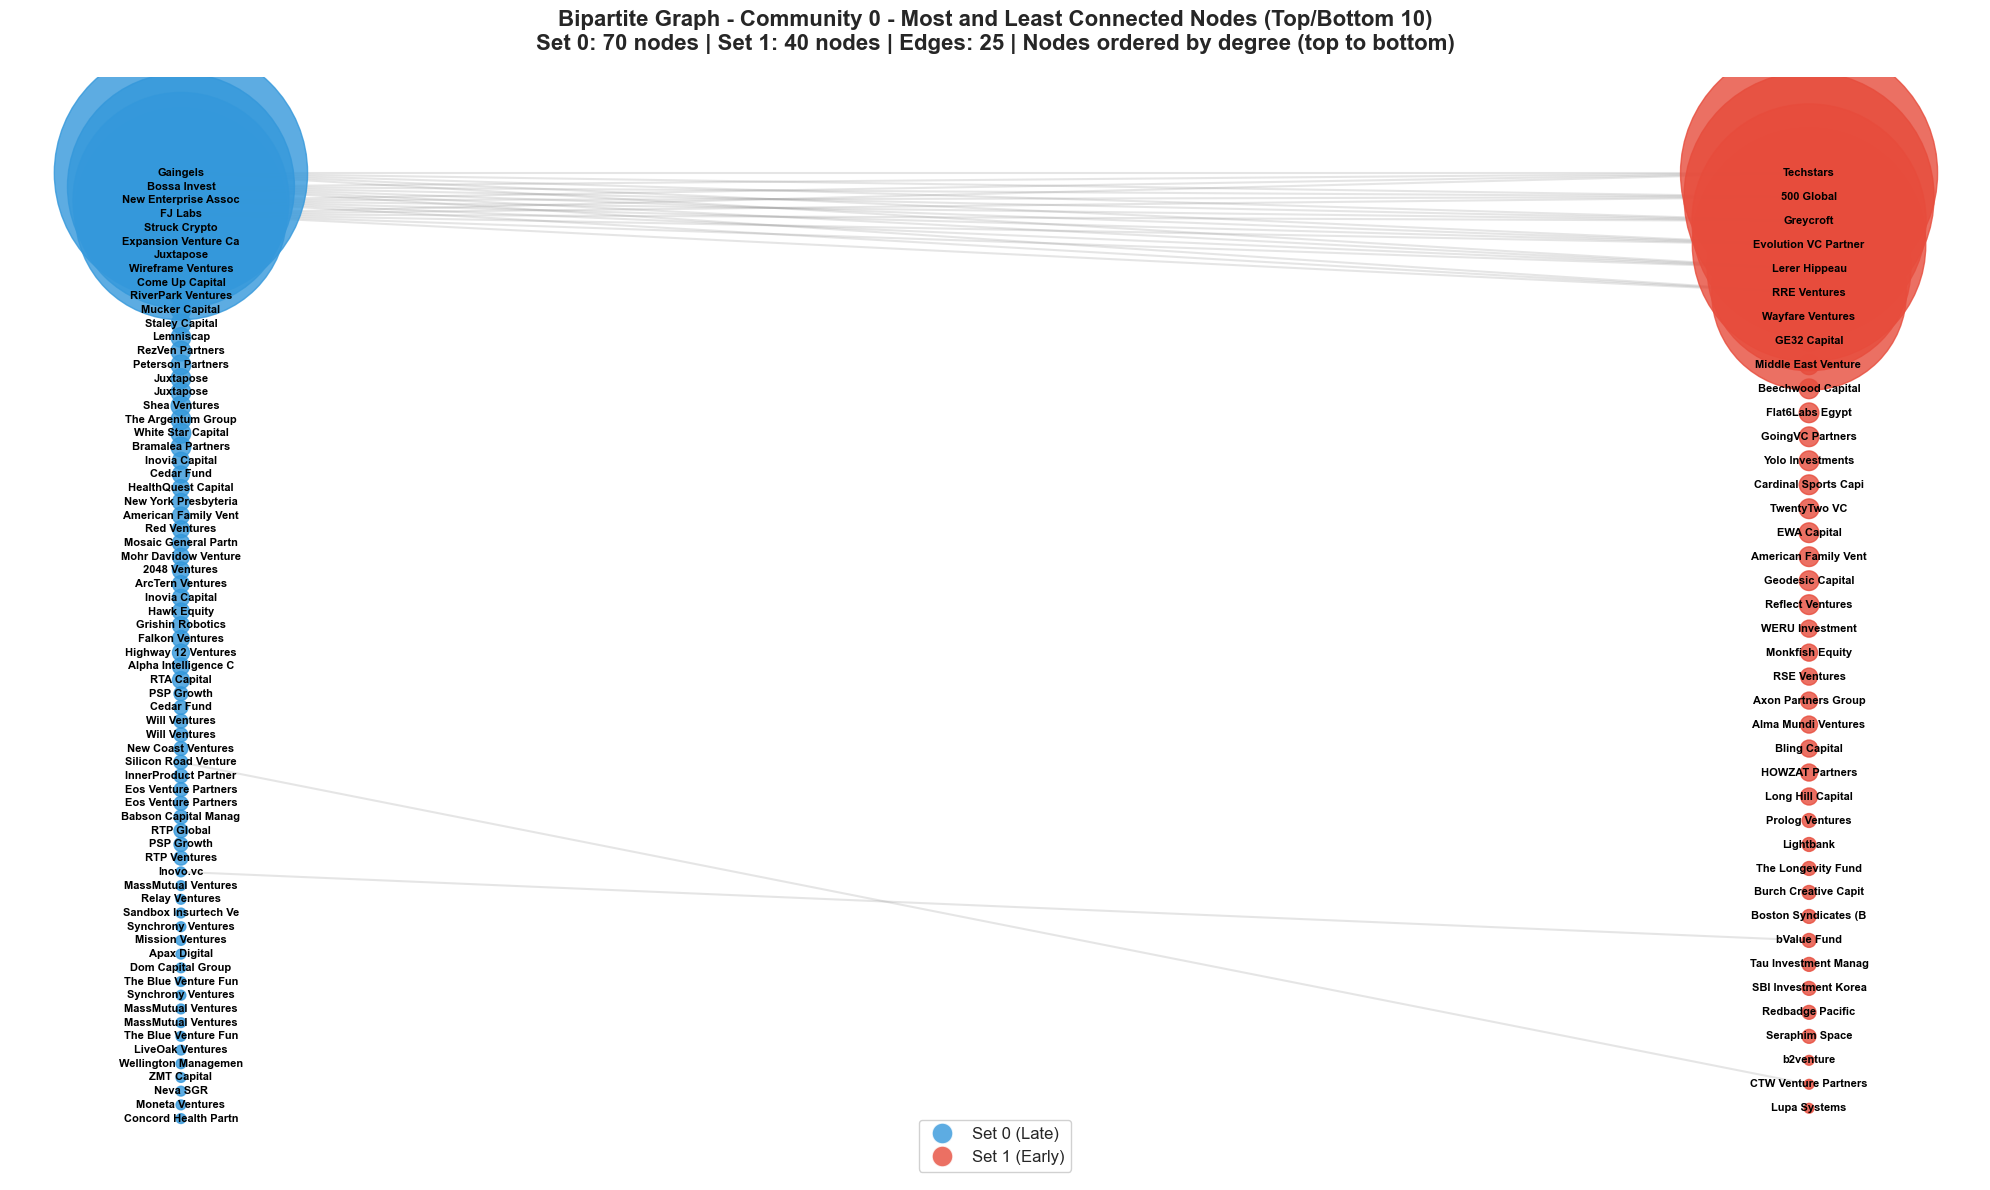

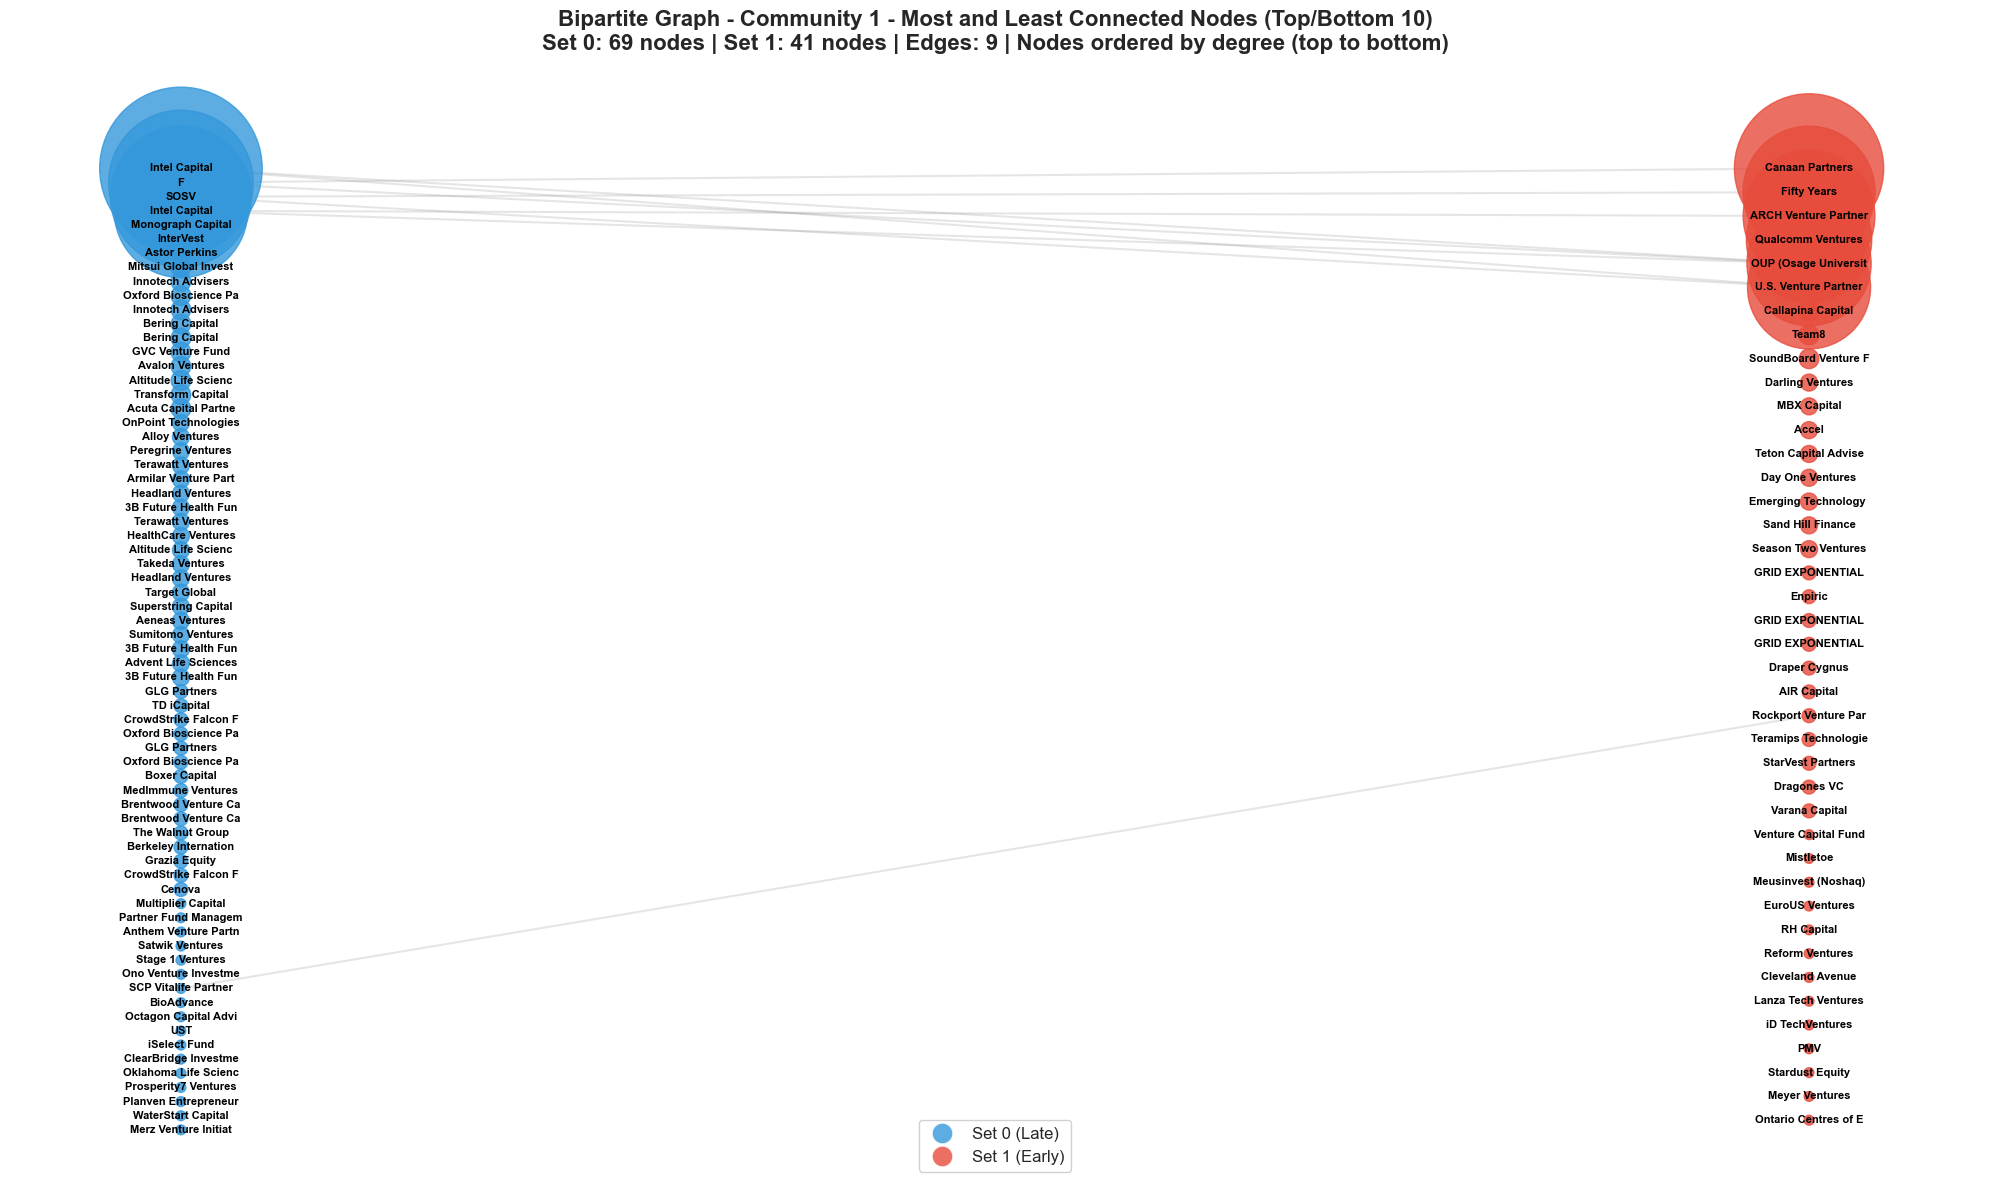

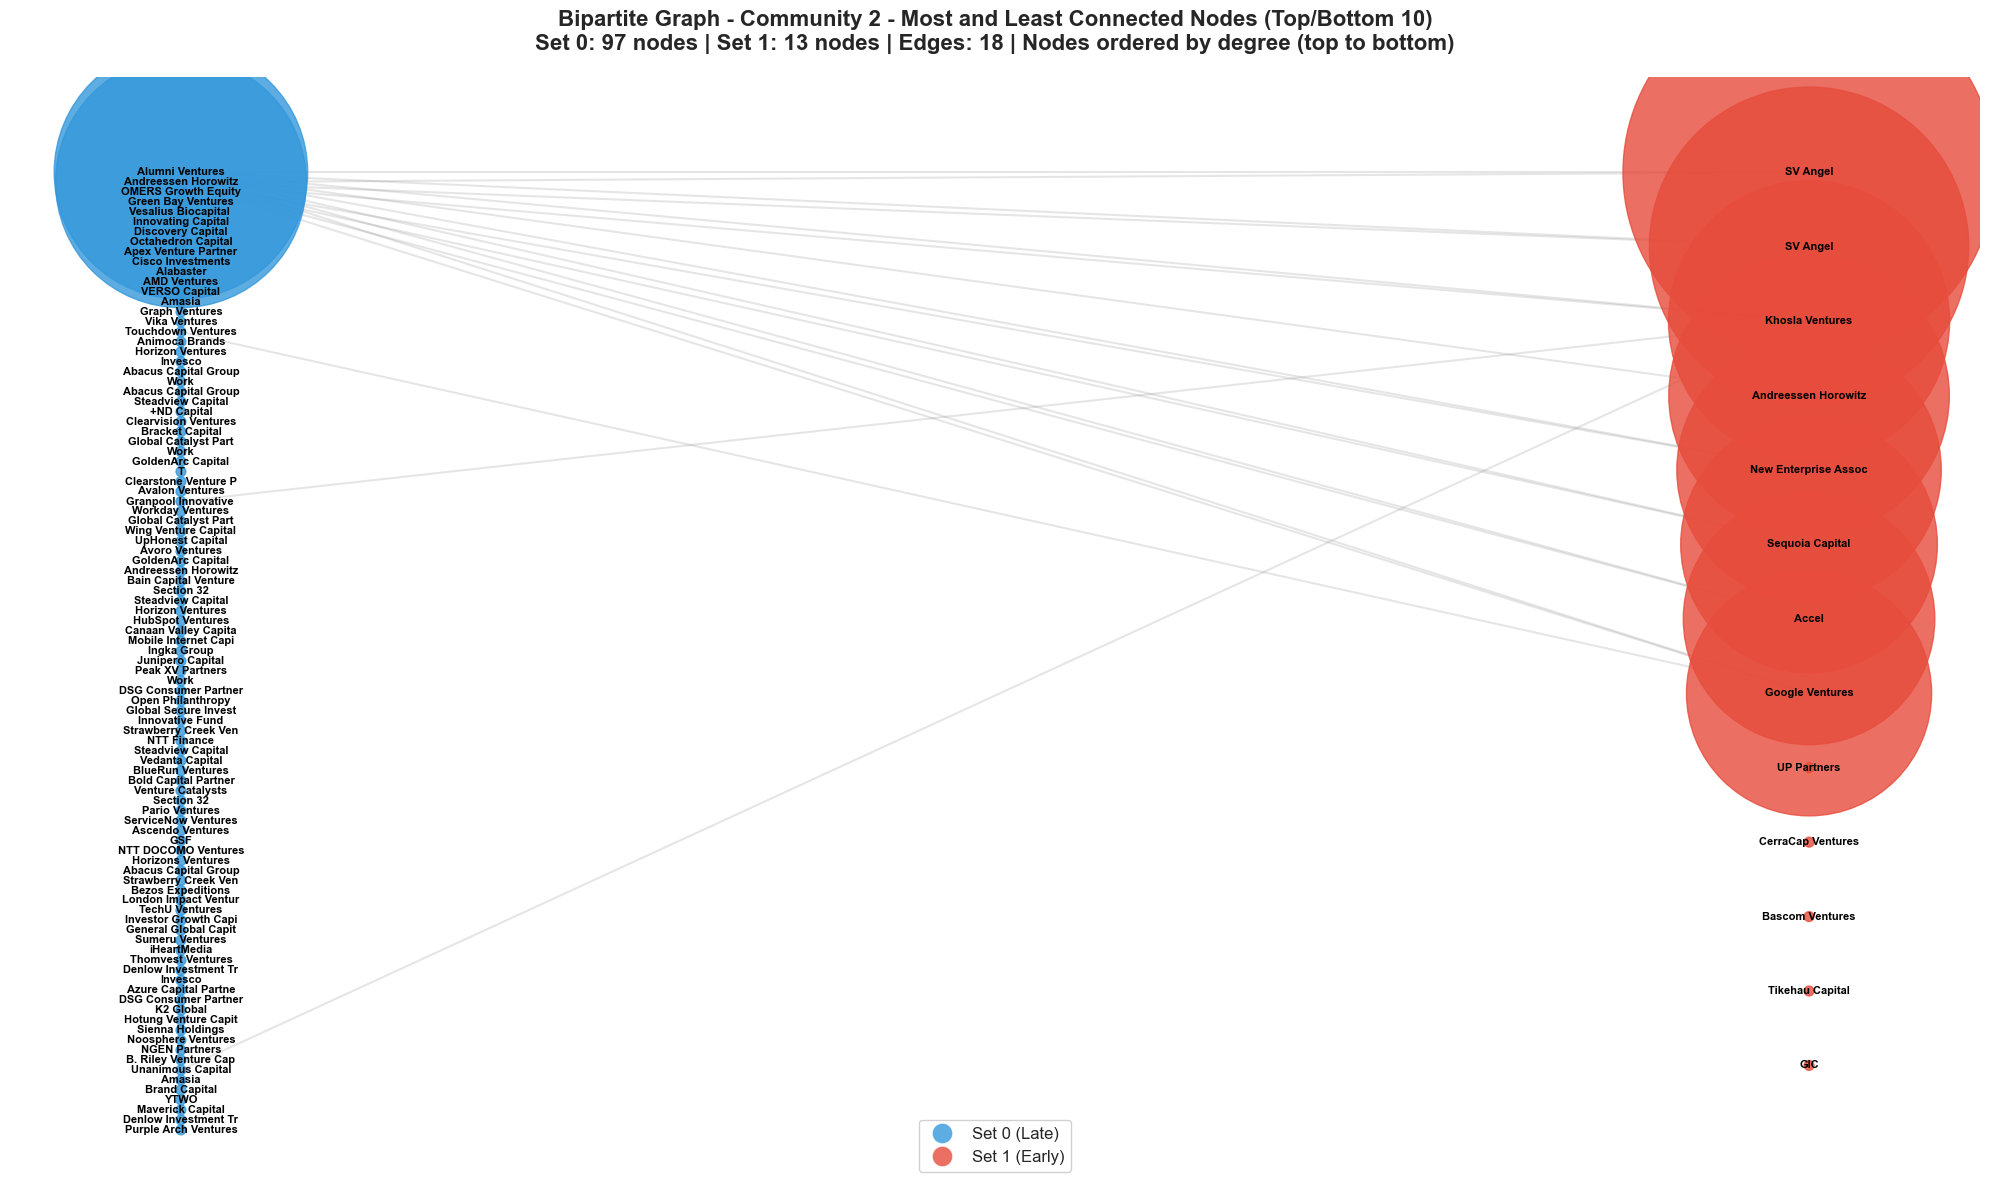

In [67]:
# Visualize bipartite graphs for communities 0, 1, 2, 3, 4
target_communities = [0, 1, 2]

for community_id in target_communities:
    print(f"\n{'='*100}")
    print(f"Processing Community {community_id}")
    print(f"{'='*100}\n")
    
    # Get top and bottom nodes (bottom nodes must be connected to top nodes)
    top_nodes, bottom_nodes = get_top_bottom_nodes(nodes_with_degree, community_id, n_top=10, n_bottom=10)
    
    # Get edges for these nodes
    top_node_ids = set(top_nodes['node'].values)
    bottom_node_ids = set(bottom_nodes['node'].values)
    all_node_ids = top_node_ids | bottom_node_ids
    
    # Filter edges where both source and target are in our node sets
    top_edges = edges_df[
        (edges_df['Source'].isin(top_node_ids)) & 
        (edges_df['Target'].isin(top_node_ids))
    ]
    
    bottom_edges = edges_df[
        (edges_df['Source'].isin(bottom_node_ids)) & 
        (edges_df['Target'].isin(bottom_node_ids))
    ]
    
    # Get edges connecting top and bottom nodes
    cross_edges = edges_df[
        ((edges_df['Source'].isin(top_node_ids)) & (edges_df['Target'].isin(bottom_node_ids))) |
        ((edges_df['Source'].isin(bottom_node_ids)) & (edges_df['Target'].isin(top_node_ids)))
    ]
    
    print(f"\nTop 20 nodes - Set distribution: "
          f"Set 0: {(top_nodes['set'] == 0).sum()}, "
          f"Set 1: {(top_nodes['set'] == 1).sum()}")
    print(f"Degree range: {top_nodes['degree'].min()} - {top_nodes['degree'].max()}")
    print(f"Edges between top nodes: {len(top_edges)}")
    
    print(f"\nBottom 20 nodes - Set distribution: "
          f"Set 0: {(bottom_nodes['set'] == 0).sum()}, "
          f"Set 1: {(bottom_nodes['set'] == 1).sum()}")
    print(f"Degree range: {bottom_nodes['degree'].min()} - {bottom_nodes['degree'].max()}")
    print(f"Edges between bottom nodes: {len(bottom_edges)}")
    print(f"Edges connecting top and bottom: {len(cross_edges)}")
    
    # Create combined nodes (top + bottom)
    combined_nodes = pd.concat([top_nodes, bottom_nodes], ignore_index=True)
    combined_node_ids = set(combined_nodes['node'].values)
    
    # Find ALL nodes connected to combined nodes (from the full edge dataset)
    edges_with_combined = edges_df[
        (edges_df['Source'].isin(combined_node_ids)) | 
        (edges_df['Target'].isin(combined_node_ids))
    ]
    
    # Get all unique node IDs that appear in these edges
    related_node_ids = set()
    related_node_ids.update(edges_with_combined['Source'].values)
    related_node_ids.update(edges_with_combined['Target'].values)
    
    # Get the full node information for all related nodes
    related_nodes = nodes_with_degree[nodes_with_degree['node'].isin(related_node_ids)].copy()
    
    print(f"\nRelated nodes analysis:")
    print(f"Combined nodes (top + bottom): {len(combined_nodes)}")
    print(f"Total related nodes (including combined): {len(related_nodes)}")
    print(f"Additional nodes connected to combined: {len(related_nodes) - len(combined_nodes)}")
    print(f"Related nodes - Set distribution: "
          f"Set 0: {(related_nodes['set'] == 0).sum()}, "
          f"Set 1: {(related_nodes['set'] == 1).sum()}")
    
    # Get all edges between related nodes
    related_node_ids_set = set(related_nodes['node'].values)
    related_edges = edges_df[
        (edges_df['Source'].isin(related_node_ids_set)) & 
        (edges_df['Target'].isin(related_node_ids_set))
    ]
    
    print(f"Total edges among related nodes: {len(related_edges)}")
    
    top_related_nodes, bottom_related_nodes = get_top_bottom_nodes(related_nodes, community_id, n_top=10, n_bottom=100)
    
    # Get edges for these nodes
    top_related_node_ids = set(top_related_nodes['node'].values)
    bottom_related_node_ids = set(bottom_related_nodes['node'].values)
    all_node_ids = top_related_node_ids | bottom_related_node_ids
    
    # Filter edges where both source and target are in our node sets
    top_related_edges = edges_df[
        (edges_df['Source'].isin(top_related_node_ids)) & 
        (edges_df['Target'].isin(top_related_node_ids))
    ]
    
    bottom_related_edges = edges_df[
        (edges_df['Source'].isin(bottom_related_node_ids)) & 
        (edges_df['Target'].isin(bottom_related_node_ids))
    ]
    
    top_bottom_related_nodes = pd.concat([top_related_nodes, bottom_related_nodes], ignore_index=True)
    top_bottom_related_edges = pd.concat([top_related_edges, bottom_related_edges, cross_edges], ignore_index=True).drop_duplicates()
    
    g = create_bipartite_graph(top_bottom_related_nodes, top_bottom_related_edges, community_id, "Most and Least Connected")
    
    print("\n")

## Step 4: Detailed Analysis - Node Degree Distribution by Community

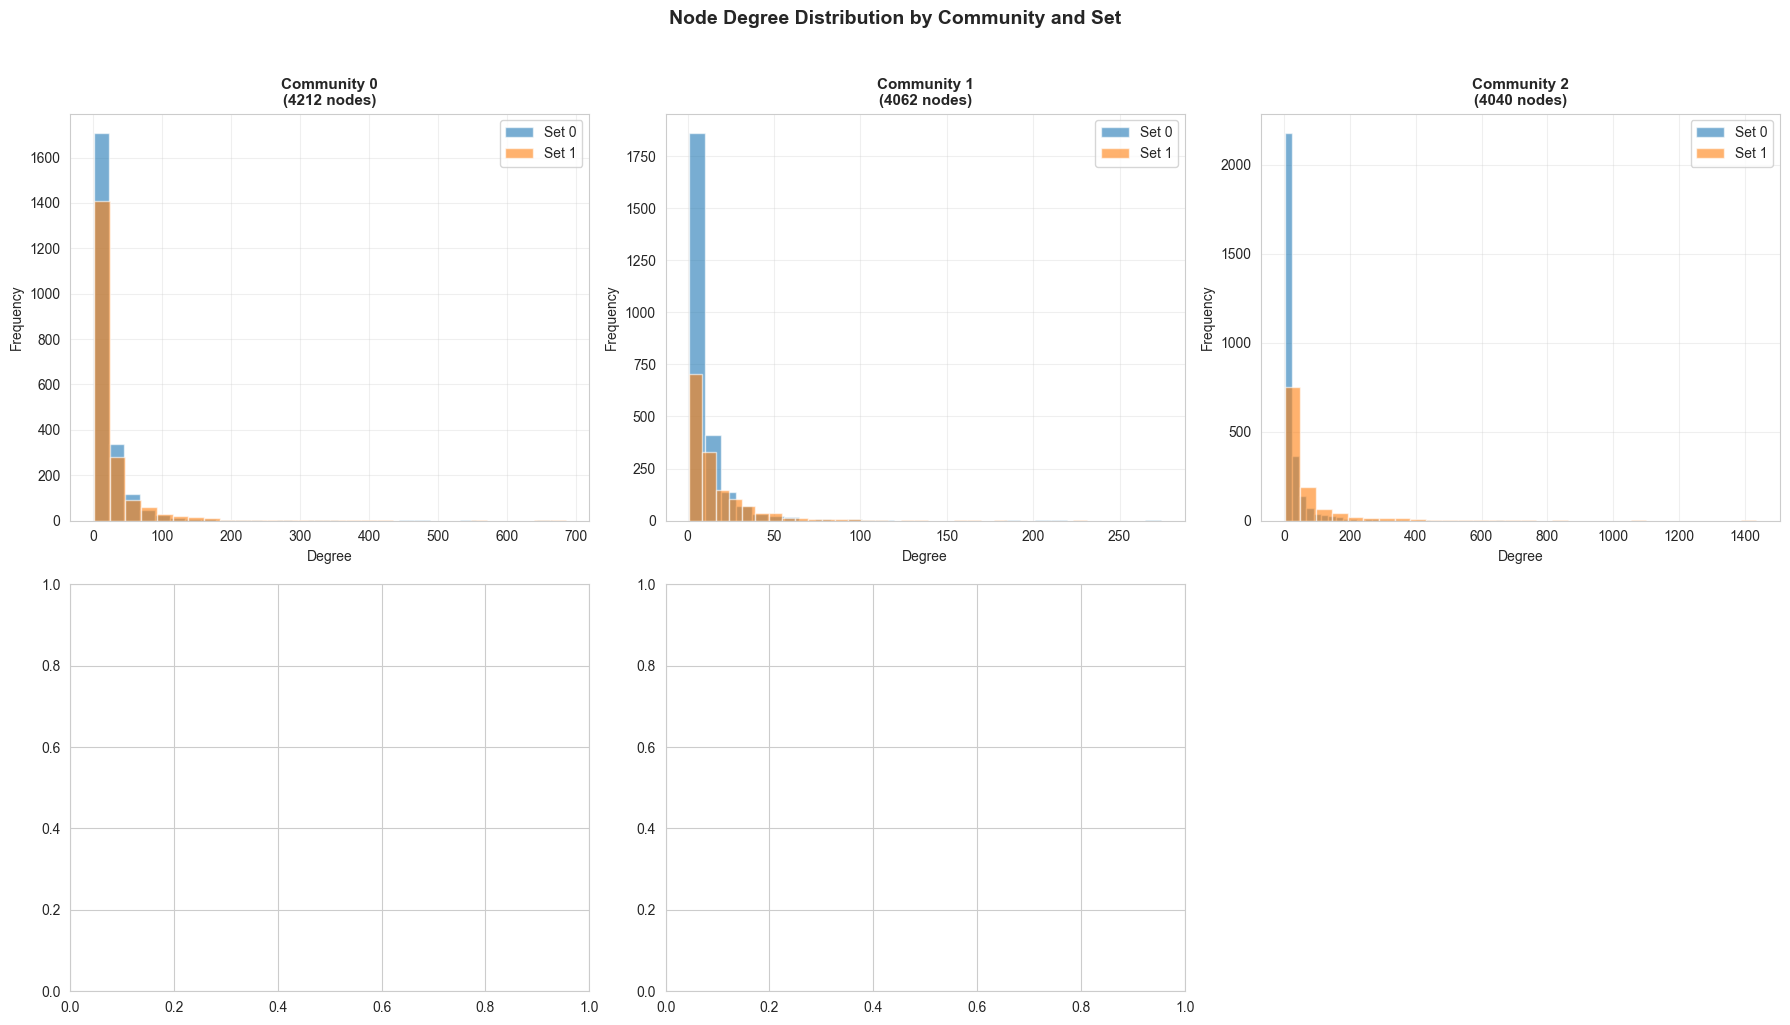

In [68]:
# Visualize degree distribution for communities 0-4
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, community_id in enumerate(target_communities):
    community_data = nodes_with_degree[nodes_with_degree['community_id'] == community_id]
    
    ax = axes[idx]
    
    # Plot degree distribution by set
    for set_val in [0, 1]:
        set_data = community_data[community_data['set'] == set_val]['degree']
        if len(set_data) > 0:
            ax.hist(set_data, bins=30, alpha=0.6, label=f'Set {set_val}')
    
    ax.set_xlabel('Degree', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'Community {community_id}\n({len(community_data)} nodes)', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

# Hide the last subplot
axes[5].axis('off')

plt.suptitle('Node Degree Distribution by Community and Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 5: Export Results

Save the nodes dataframe with degree information for further analysis.

In [69]:
# Save the nodes dataframe with degree information
output_path = '../data/processed/us/nodes_with_degree.csv'
nodes_with_degree.to_csv(output_path, index=False)
print(f"Saved nodes with degree data to: {output_path}")

# Display final dataframe summary
print(f"\nFinal DataFrame shape: {nodes_with_degree.shape}")
print(f"\nColumns: {nodes_with_degree.columns.tolist()}")
print(f"\nSample of final data:")
print(nodes_with_degree.head(10))

Saved nodes with degree data to: ../data/processed/us/nodes_with_degree.csv

Final DataFrame shape: (15347, 8)

Columns: ['index', 'index.1', 'community_id', 'node', 'community_size', 'id', 'set', 'degree']

Sample of final data:
   index  index.1  community_id                                 node  \
0      0        0             0         Ironspring Ventures-series_a   
1      1        1             0                        Bolt-series_a   
2      2        2             0                 NightDragon-series_e   
3      3        3             0                       Xfund-series_e   
4      4        4             0          Borderless Capital-series_b   
5      5        5             0            Blueprint Equity-series_a   
6      6        6             0  Hyde Park Venture Partners-series_b   
7      7        7             0                 GOS Capital-series_b   
8      8        8             0             Voyager Capital-series_b   
9      9        9             0                 Bu